In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Instagram_dataset.csv")

In [3]:
df.info

<bound method DataFrame.info of          post_id  account_id account_type  follower_count media_type  \
0      IG0000001           7        brand            3551       reel   
1      IG0000002          20      creator           31095      image   
2      IG0000003          15        brand            8167       reel   
3      IG0000004          11      creator            9044   carousel   
4      IG0000005           8      creator           15986       reel   
...          ...         ...          ...             ...        ...   
29994  IG0029995           5        brand           10739   carousel   
29995  IG0029996           3        brand           10018      image   
29996  IG0029997          18      creator            7486      image   
29997  IG0029998           6      creator           10034   carousel   
29998  IG0029999           9      creator            6916      image   

      content_category traffic_source  has_call_to_action   post_date  \
0           Technology      Home Feed                   1  30-11-2024   
1              Fitness       Hashtags                   1  15-08-2025   
2               Beauty     Reels Feed                   0  11-09-2025   
3                Music       External                   0  18-09-2025   
4           Technology        Profile                   0  21-03-2025   
...                ...            ...                 ...         ...   
29994           Travel     Reels Feed                   0  18-12-2024   
29995           Beauty       Hashtags                   0  05-05-2025   
29996      Photography        Explore                   1  26-05-2025   
29997       Technology        Explore                   1  02-08-2025   
29998       Technology        Explore                   1  15-04-2025   

       post_time  ... comments  shares  saves  reach  impressions  \
0              6  ...        5       7     34   4327         6230   
1             15  ...       10      21     68   7451         8268   
2             16  ...        2       1     22   1639         2616   
3              3  ...        0       7      0   2877         3171   
4              9  ...        8       5     21   5350         8503   
...          ...  ...      ...     ...    ...    ...          ...   
29994         10  ...        1       2      5   1564         2493   
29995         15  ...        2       1      7   2042         2492   
29996         10  ...       10      16     59   5887         7528   
29997         19  ...        3       0     19   5372         6312   
29998         20  ...        1       1      5   4019         5678   

       engagement_rate  followers_gained  caption_length  hashtags_count  \
0               0.0385               899             100               7   
1               0.0663               805             122               5   
2               0.0531               758             115               8   
3               0.0309               402             115               7   
4               0.0221               155             112               9   
...                ...               ...             ...             ...   
29994           0.0032               124             127               8   
29995           0.0209               310             114              12   
29996           0.0558               223             115               4   
29997           0.0333               978             124               4   
29998           0.0100               272             126              11   

       performance_bucket_label  
0                        medium  
1                         viral  
2                          high  
3                        medium  
4                           low  
...                         ...  
29994                       low  
29995                       low  
29996                      high  
29997                    medium  
29998                       low  

[29999 rows x 22 columns]>

In [5]:
df.shape

(29999, 22)

In [6]:
df.columns

Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action', 'post_date',
       'post_time', 'day_of_week', 'likes', 'comments', 'shares', 'saves',
       'reach', 'impressions', 'engagement_rate', 'followers_gained',
       'caption_length', 'hashtags_count', 'performance_bucket_label'],
      dtype='object')

In [7]:
df.dtypes

,0
post_id,object
account_id,int64
account_type,object
follower_count,int64
media_type,object
content_category,object
traffic_source,object
has_call_to_action,int64
post_date,object
post_time,int64


In [10]:
df.isnull().sum()

,0
post_id,0
account_id,0
account_type,0
follower_count,0
media_type,0
content_category,0
traffic_source,0
has_call_to_action,0
post_date,0
post_time,0


In [11]:
df = df.drop_duplicates()

In [12]:

df = df[(df['likes'] >= 0) & (df['comments'] >= 0)]

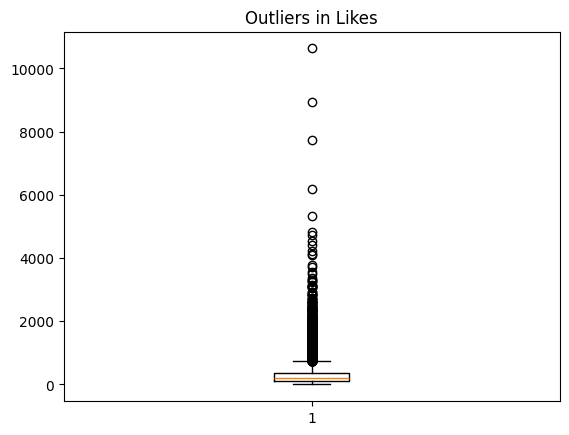

In [13]:
plt.boxplot(df['likes'])
plt.title("Outliers in Likes")
plt.show()

In [15]:
def hashtag_category(x):
    if x <= 5:
        return "Low"
    elif x <= 10:
        return "Medium"
    else:
        return "High"

df['hashtag_category'] = df['hashtags_count'].apply(hashtag_category)

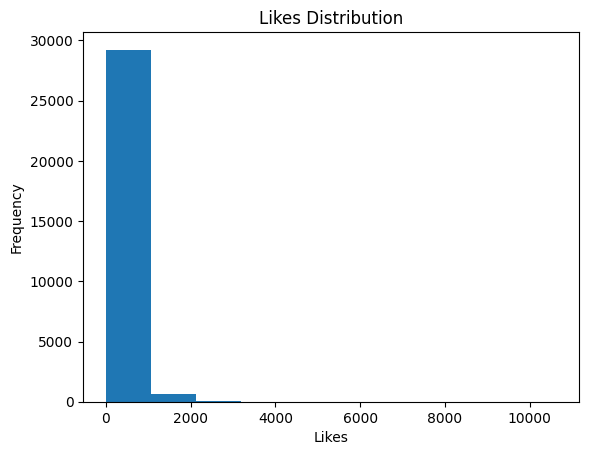

In [16]:
plt.hist(df['likes'])
plt.title("Likes Distribution")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

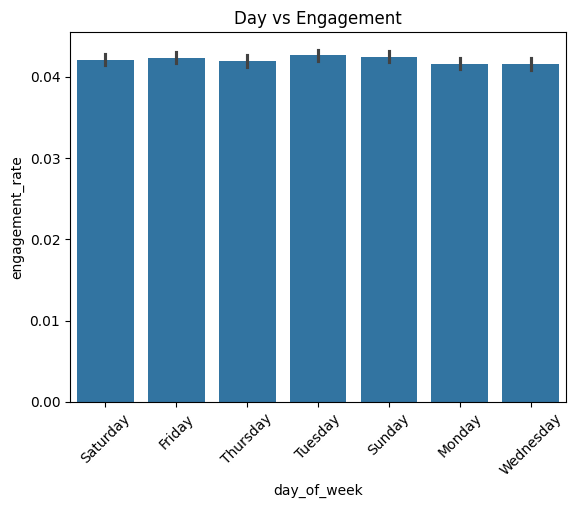

In [21]:
sns.barplot(x='day_of_week', y='engagement_rate', data=df)
plt.xticks(rotation=45)
plt.title("Day vs Engagement")
plt.show()

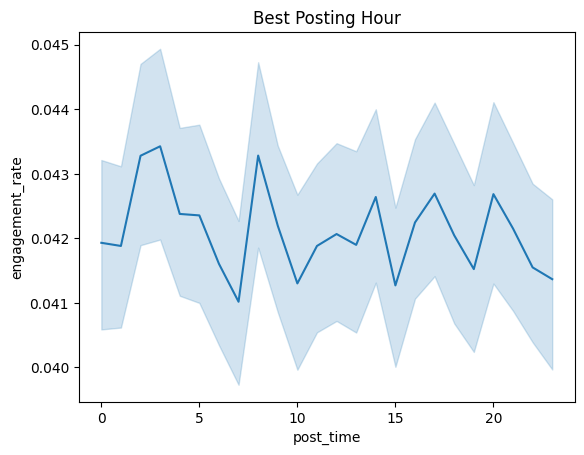

In [23]:
sns.lineplot(x='post_time', y='engagement_rate', data=df)
plt.title("Best Posting Hour")
plt.show()

In [24]:
top_posts = df.sort_values(by='engagement_rate', ascending=False).head(5)
top_posts

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_date,post_time,...,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label,hashtag_category
5226,IG0005227,3,brand,10018,carousel,Food,Hashtags,1,19-10-2025,13,...,51,246,6073,6742,0.2710,431,111,6,viral,Medium
17614,IG0017615,17,creator,15923,reel,Comedy,Hashtags,0,20-11-2024,4,...,51,195,4546,5023,0.2658,450,106,12,viral,High
9303,IG0009304,10,creator,4542,carousel,Photography,Explore,0,06-05-2025,5,...,57,246,5939,6686,0.2544,896,122,6,viral,Medium
17636,IG0017637,4,creator,4972,image,Beauty,External,1,06-11-2025,20,...,24,108,2745,3141,0.2531,924,136,8,viral,Medium
17986,IG0017987,7,brand,3551,image,Beauty,External,1,09-08-2025,3,...,213,552,14964,17627,0.2527,921,120,11,viral,High


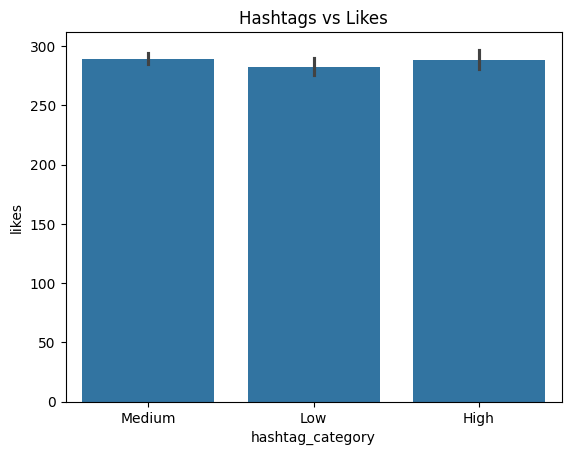

In [25]:
sns.barplot(x='hashtag_category', y='likes', data=df)
plt.title("Hashtags vs Likes")
plt.show()